In [1]:
import pandas as pd
from pathlib import Path

DATA_RAW = Path("../data/raw").resolve()

csv_file = next(DATA_RAW.glob("*.csv"))

df = pd.read_csv(csv_file)

X = df.iloc[:, 1:]

print("Shape:", X.shape)

Shape: (3000, 365)


In [2]:
X_filled = X.fillna(X.mean())

print("Missing values after filling:",
      X_filled.isnull().sum().sum())

Missing values after filling: 0


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_filled)

print("Scaled shape:", X_scaled.shape)

Scaled shape: (3000, 365)


In [4]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

print("Clusters:", set(cluster_labels))

Clusters: {np.int32(0), np.int32(1), np.int32(2), np.int32(3)}


In [5]:
cluster_df = pd.DataFrame({
    "ID": df["ID"],
    "Cluster": cluster_labels
})

cluster_df.head()

,ID,Cluster
0,acem--ilahi--duyek--aldanma_dunya--zekai_dede,3
1,acem--ilahi--nimevsat--calabim_bir--haci_bayra...,1
2,acem--kupe--duyek--zulfunu--ahmet_avni_konuk,2
3,acem--selam--devrikebir--asik-i_ger--huseyin_f...,3
4,acem--seyir--sofyan----sefik_gurmeric,1


In [6]:
cluster_counts = cluster_df.groupby("Cluster").size()

print(cluster_counts)

Cluster
0     609
1     925
2     203
3    1263
dtype: int64


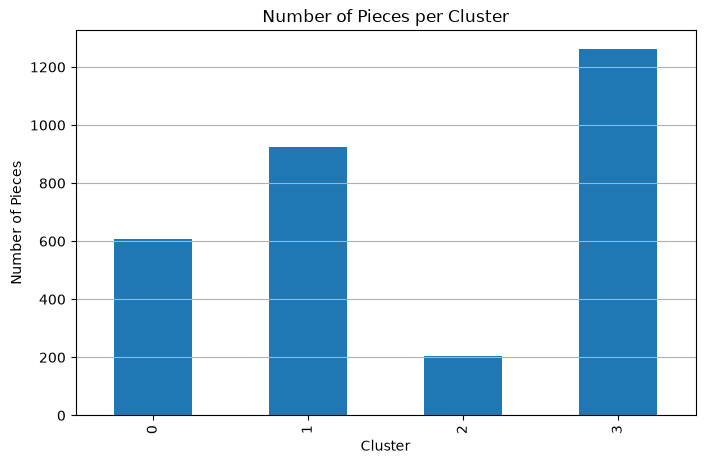

In [7]:
import matplotlib.pyplot as plt

cluster_counts.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Number of Pieces per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Pieces")

plt.grid(axis="y")

plt.show()

In [8]:
for c in sorted(cluster_df["Cluster"].unique()):

    print("\n====================")
    print(f"Cluster {c}")
    print("====================")

    examples = cluster_df[
        cluster_df["Cluster"] == c
    ]["ID"].head(10)

    for piece in examples:
        print(piece)


Cluster 0
acemasiran--agirsemai--senginsemai--ey_lebleri--dede_efendi
acemasiran--aranagme--aksak--1--
acemasiran--pesrev--devrikebir----dede_salih_efendi
acemasiran--sarki--agiraksak--bir_teselli--serif_icli
acemasiran--sarki--agirduyek--kime_halim--faize_ergin
acemasiran--sarki--aksak--gordum_seni--irfan_dogrusoz
acemasiran--sarki--aksak--oldu_gonul--dede_efendi
acemasiran--sarki--aksak--o_tebessum--ismail_baha_surelsan
acemasiran--sarki--curcuna--neden_kalbim--nasibin_mehmet_yuru
acemasiran--sarki--devrihindi--ruy-i_alemdir--dellalzade_haci_ismail_efendi

Cluster 1
acem--ilahi--nimevsat--calabim_bir--haci_bayram_veli
acem--seyir--sofyan----sefik_gurmeric
acemasiran--aranagme--agiraksak--1--
acemasiran--aranagme--sofyan--1--
acemasiran--pesrev--frenkcin----nuri_halil_poyraz
acemasiran--pesrev--muhammes----gazi_giray_han
acemasiran--sarki--aksak--dinle_sozum--iii_selim
acemasiran--sarki--curcuna--ates-i_askinla--emin_ongan
acemasiran--sarki--duyek--sim-ten_gonca--sakir_aga
acemasiran

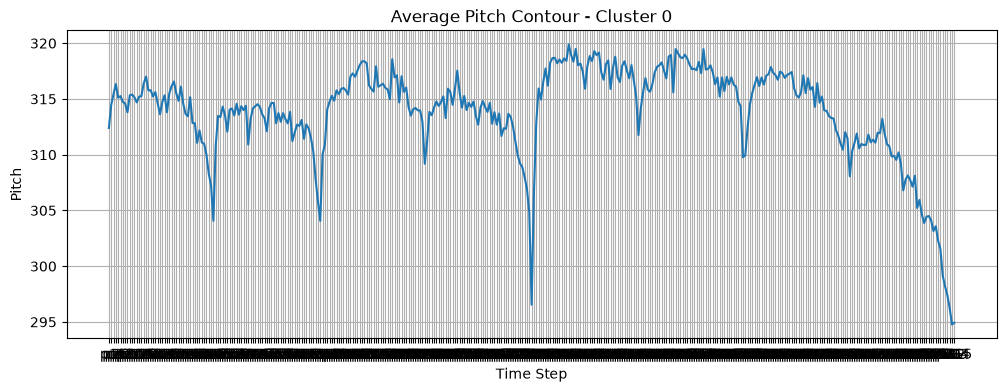

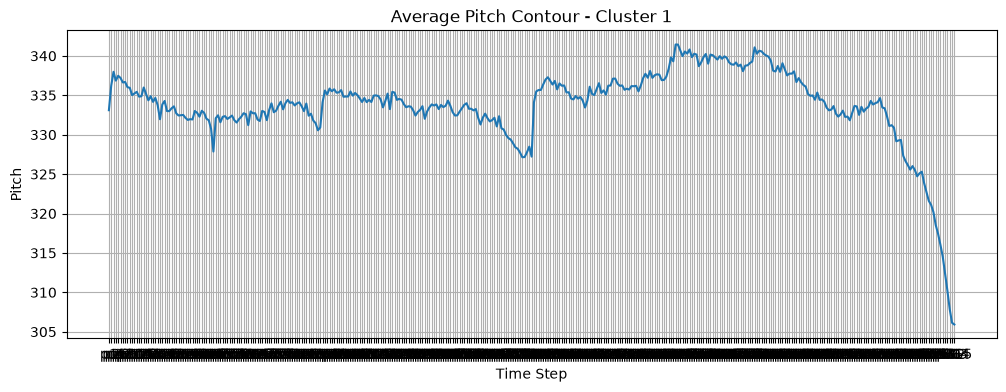

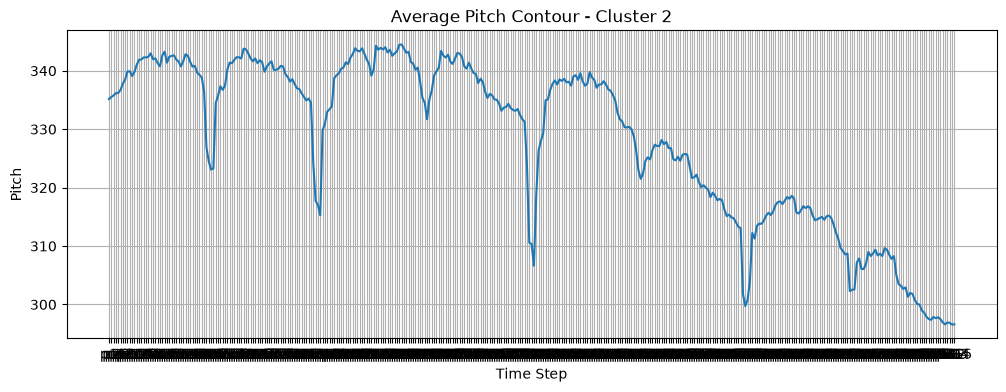

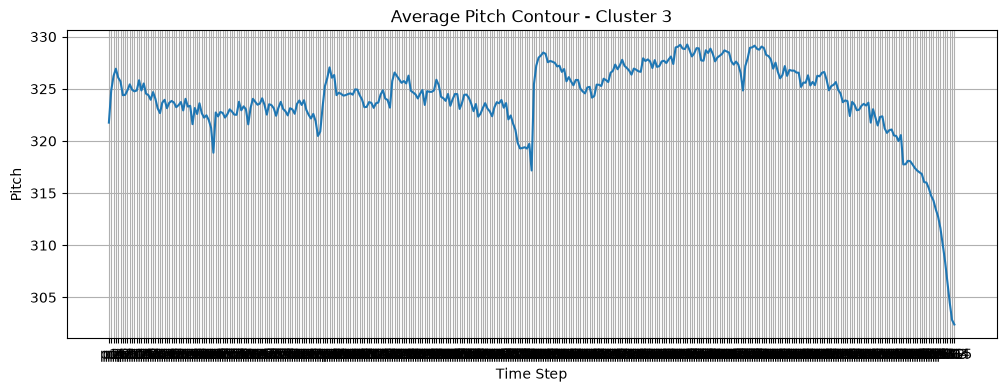

In [9]:
for cluster in sorted(set(cluster_labels)):

    mean_curve = X_filled[
        cluster_labels == cluster
    ].mean(axis=0)

    plt.figure(figsize=(12,4))

    plt.plot(mean_curve)

    plt.title(
        f"Average Pitch Contour - Cluster {cluster}"
    )

    plt.xlabel("Time Step")
    plt.ylabel("Pitch")

    plt.grid(True)

    plt.show()

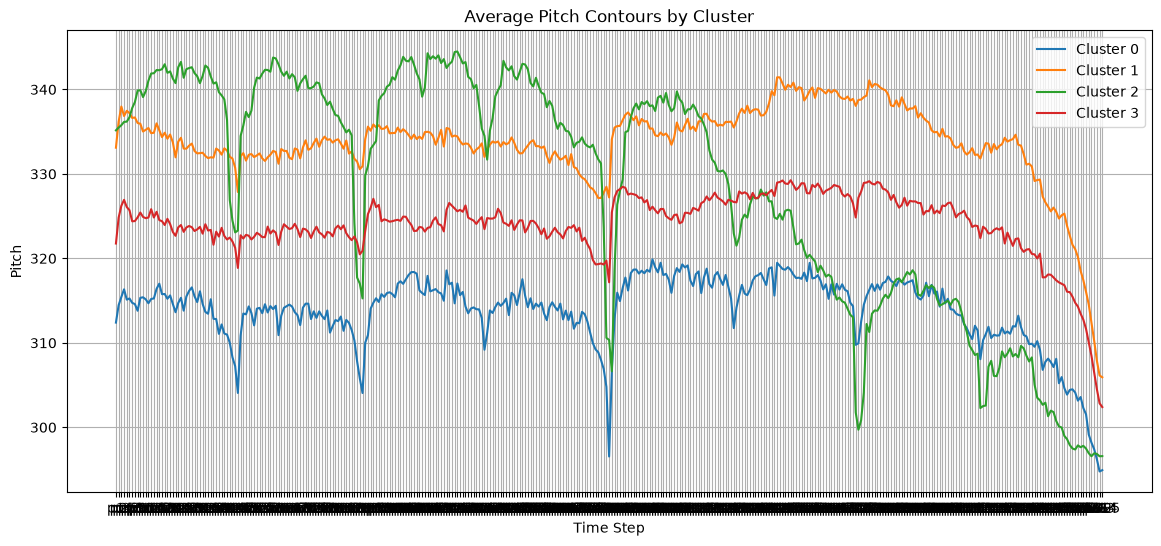

In [10]:
plt.figure(figsize=(14,6))

for cluster in sorted(set(cluster_labels)):

    mean_curve = X_filled[
        cluster_labels == cluster
    ].mean(axis=0)

    plt.plot(
        mean_curve,
        label=f"Cluster {cluster}"
    )

plt.title("Average Pitch Contours by Cluster")

plt.xlabel("Time Step")
plt.ylabel("Pitch")

plt.legend()

plt.grid(True)

plt.show()

## Interpretation

The clusters obtained by K-Means represent groups of pieces with similar pitch trajectory characteristics.

The average pitch contour plots provide a first indication of the melodic behavior of each cluster.

Further musicological investigation is required to determine whether the clusters correspond to maqam families, stylistic categories, or other structural characteristics.